In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()
SRC_PATH = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / 'data/20_years'

os.chdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scr.data.load_data import load_data_from_csv
from notebooks.utils import get_predictions, get_predictions_transformer, get_predictions_quarterly_models
from scr.trade.trading_strategy import moving_average_strategy
from scr.trade.backtest import simulate_trades_with_allocation
from notebooks.utils import daily_sharpe_ratio, plot_dynamic_sharpe_ratio, plot_daily_returns, plot_cumulative_returns_baseline

def trim_predictions_to_length(predictions, actuals, target_length):
    """Trim all series to the same evaluation window length."""
    trimmed_predictions = {}
    trimmed_actuals = {}

    for ticker in predictions:
        if ticker not in actuals:
            continue

        if len(predictions[ticker]) < target_length or len(actuals[ticker]) < target_length:
            raise ValueError(
                f"{ticker} is shorter than the requested window length {target_length}."
            )

        trimmed_predictions[ticker] = predictions[ticker][-target_length:]
        trimmed_actuals[ticker] = actuals[ticker][-target_length:]

    return trimmed_predictions, trimmed_actuals

In [ ]:
tickers = ['GOOGL', 'AMZN', 'AAPL', 'PEP', 'JNJ', 'PFE', 'MRK', 'ABBV', 'PG', 'KO',
           'WMT', 'JPM', 'BAC', 'GS', 'V', 'XOM', 'CVX', 'COP', 'BP', 'BA',
           'MMM', 'HON', 'GE', 'T', 'VZ', 'TMUS', 'HSY', 'DUK', 'SO', 'EXC', 'AEP',
           'AMT', 'PLD', 'SPG', 'BHP', 'RIO', 'VALE', 'FCX']

simulation_start_date = '2021-01-01'
simulation_end_date = '2023-10-23'

sequence_length = 50

quarterly_data_start_date = '2013-01-01'
data_end_date = '2023-10-23'

 # LSTM 13 years training

In [4]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_13_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_13_years'

In [5]:
# Load models and get predictions
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

reference_window_length = min(len(series) for series in predictions.values())
predictions, actuals = trim_predictions_to_length(predictions, actuals, reference_window_length)

# Trading strategy
trading_signals = moving_average_strategy(predictions)

# Backtest the strategy
portfolio_returns = simulate_trades_with_allocation(predictions, actuals, trading_signals, initial_capital=100000, allocation_percentage=0.1, slippage_rate=0.02, transaction_cost=0.005)

# Evaluate performance
sharpe_ratio = daily_sharpe_ratio(portfolio_returns)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Processing GOOGL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Processing AMZN...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AAPL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Processing PEP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Processing JNJ...


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing BHP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing RIO...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing VALE...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing FCX...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Sharpe Ratio: -0.3609


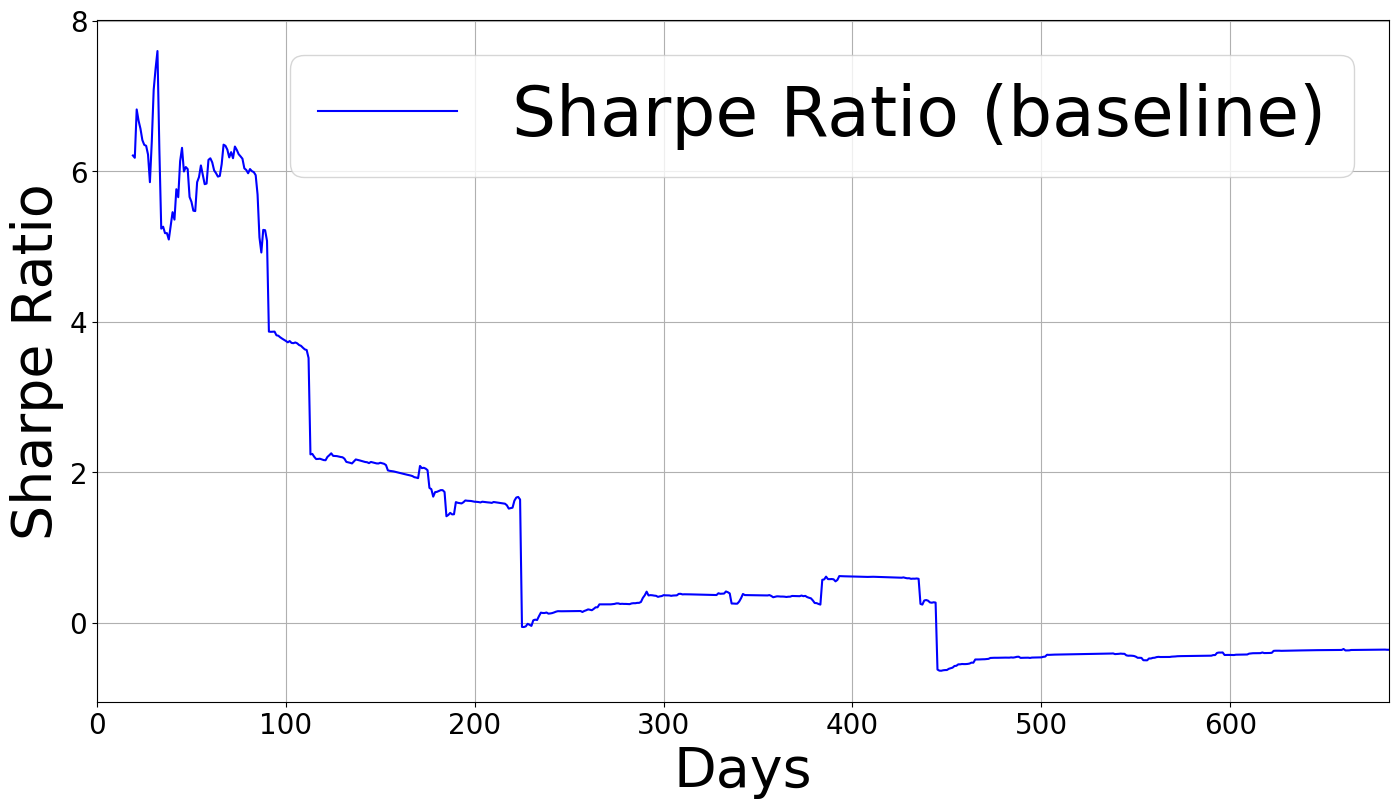

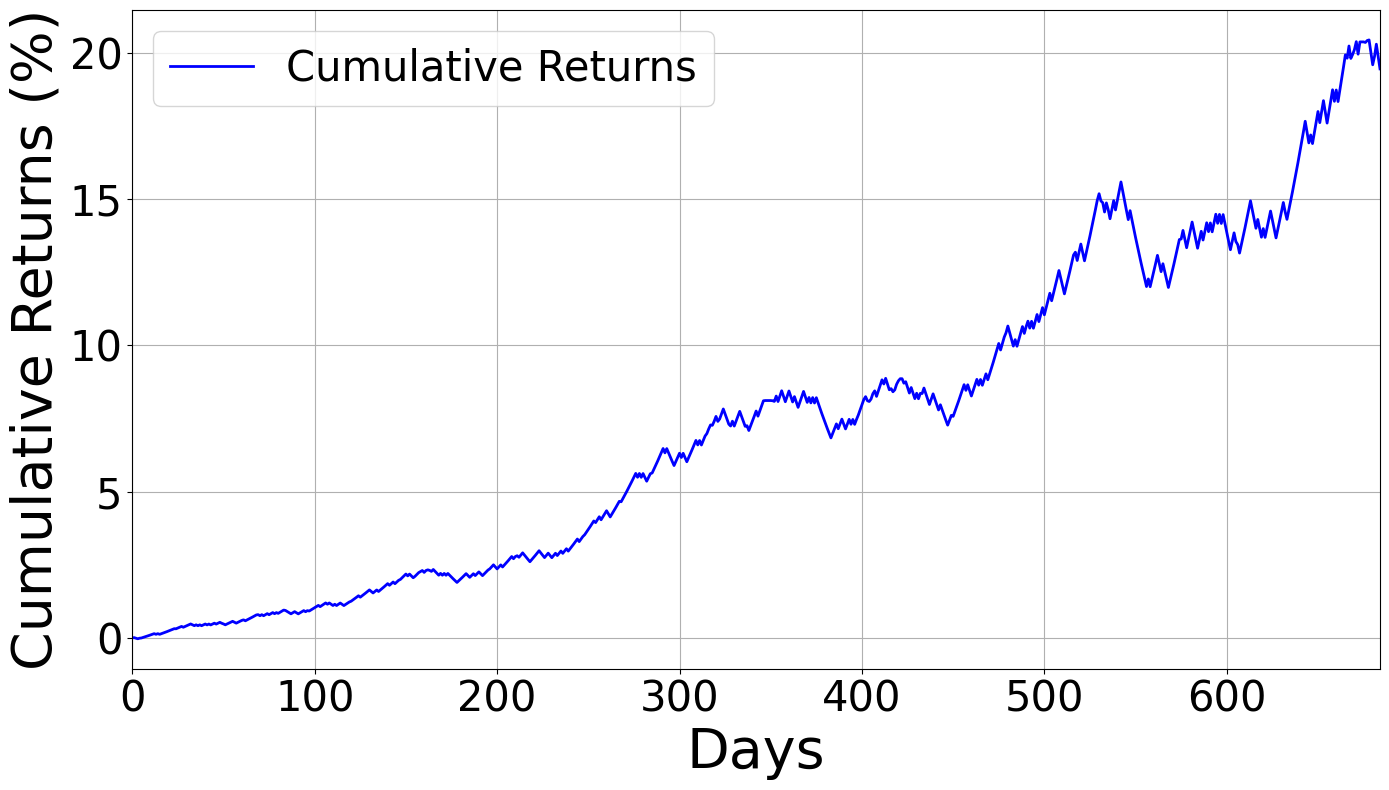

In [6]:
plot_dynamic_sharpe_ratio(portfolio_returns, folder=PLOTS_DIR)


plot_cumulative_returns_baseline(portfolio_returns, folder=PLOTS_DIR)

# LSTM 3 years training

In [7]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_3_years'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_3_years'

In [8]:
# Load models and get predictions
predictions, actuals = get_predictions(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    MODEL_DIR,
    use_partition_dataset=False,
)

predictions, actuals = trim_predictions_to_length(predictions, actuals, reference_window_length)

# Trading strategy
trading_signals = moving_average_strategy(predictions)

# Backtest the strategy
portfolio_returns = simulate_trades_with_allocation(predictions, actuals, trading_signals, initial_capital=100000, allocation_percentage=0.1, slippage_rate=0.02, transaction_cost=0.005)

# Evaluate performance
sharpe_ratio = daily_sharpe_ratio(portfolio_returns)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Processing GOOGL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AMZN...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing AAPL...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing PEP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Processing JNJ...


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing BHP...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing RIO...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing VALE...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Processing FCX...


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Sharpe Ratio: 0.4608


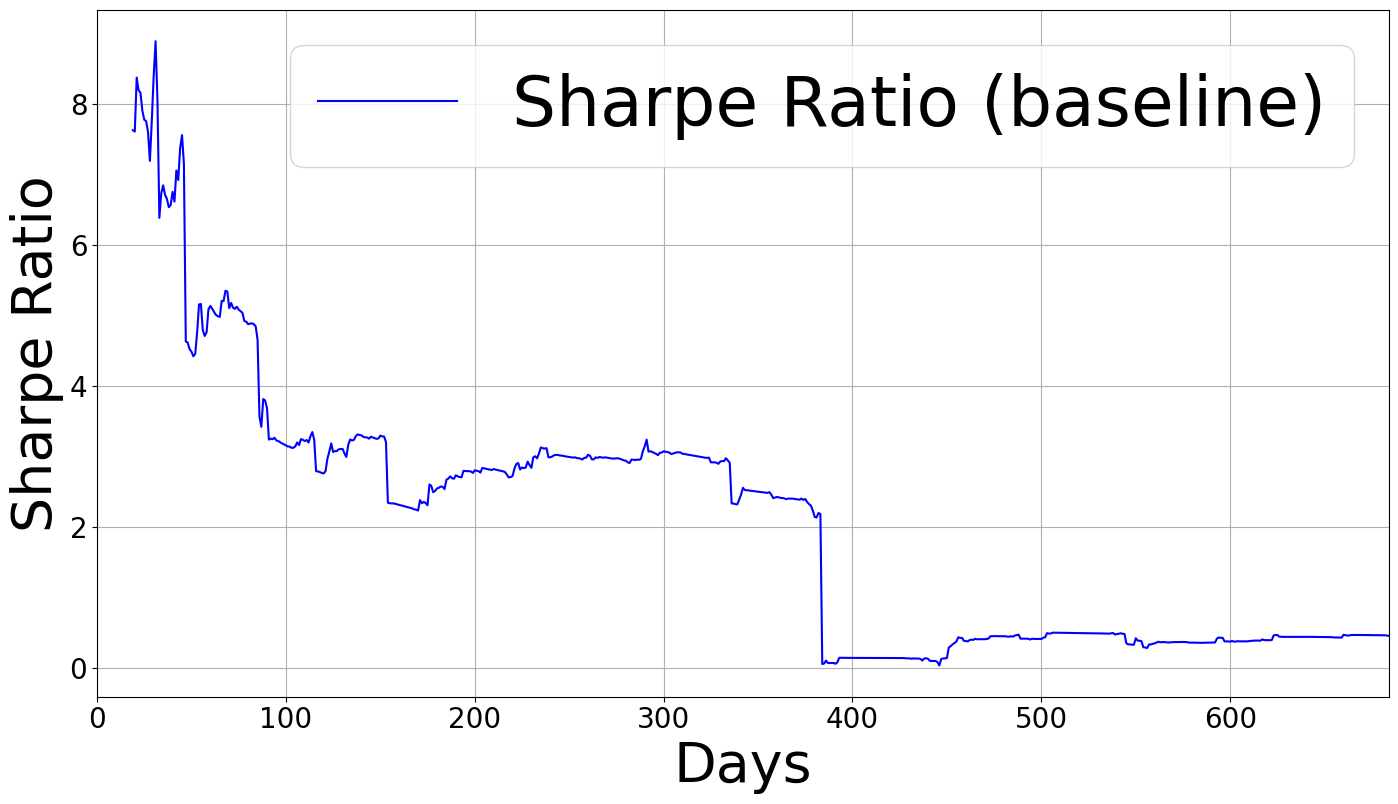

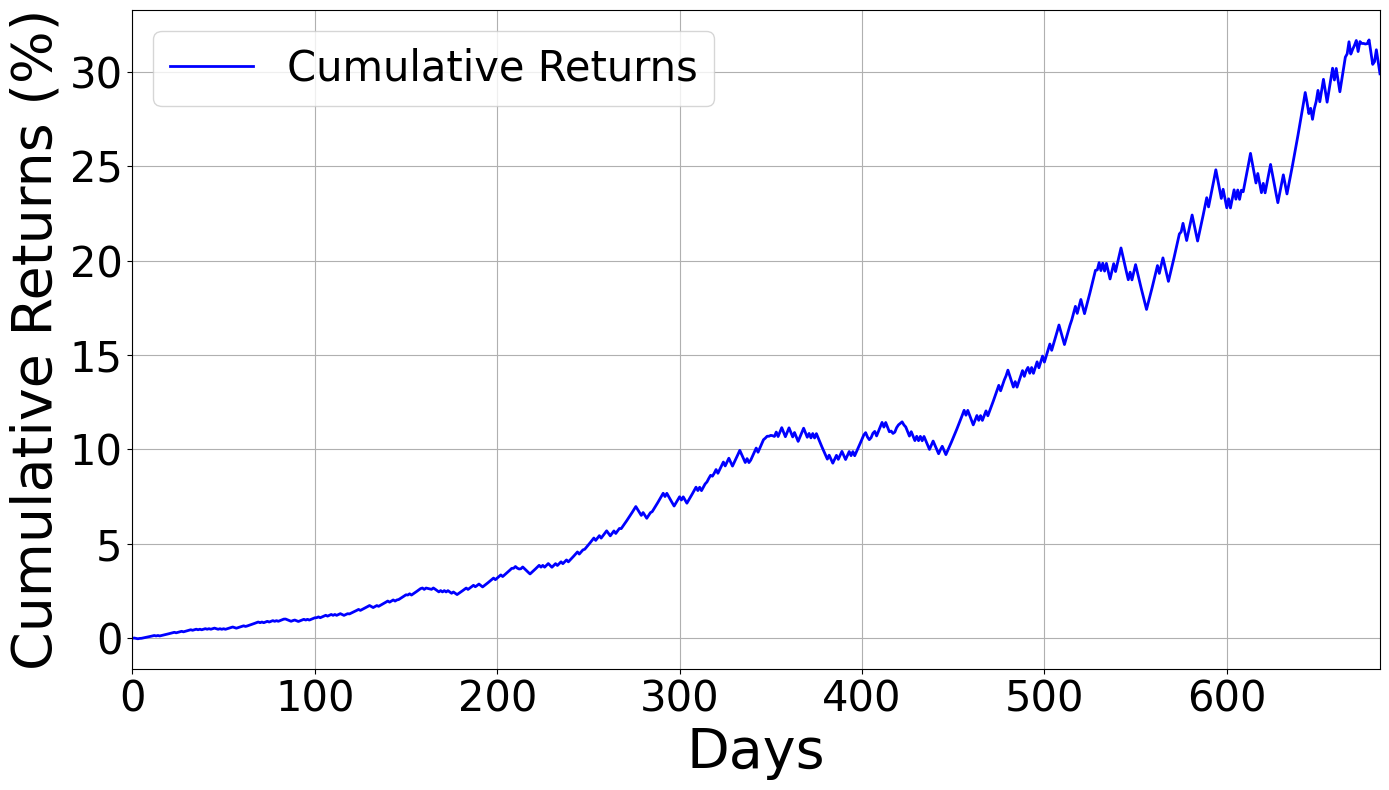

In [9]:
plot_dynamic_sharpe_ratio(portfolio_returns, folder=PLOTS_DIR)


plot_cumulative_returns_baseline(portfolio_returns, folder=PLOTS_DIR)

# LSTM quarterly cumulative retrain

In [10]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_cumulative'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_cumulative'

In [11]:
# Load models and get predictions
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="cumulative"
)

predictions, actuals = trim_predictions_to_length(predictions, actuals, reference_window_length)

# Trading strategy
trading_signals = moving_average_strategy(predictions)

# Backtest the strategy
portfolio_returns = simulate_trades_with_allocation(predictions, actuals, trading_signals, initial_capital=100000, allocation_percentage=0.1, slippage_rate=0.02, transaction_cost=0.005)

# Evaluate performance
sharpe_ratio = daily_sharpe_ratio(portfolio_returns)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Processing GOOGL...


Processing AMZN...
Processing AAPL...
Processing PEP...
Processing JNJ...
Processing PFE...
Processing MRK...
Processing ABBV...
Processing PG...
Processing KO...
Processing WMT...
Processing JPM...
Processing BAC...
Processing GS...
Processing V...
Processing XOM...
Processing CVX...
Processing COP...
Processing BP...
Processing BA...
Processing MMM...
Processing HON...
Processing GE...
Processing T...
Processing VZ...
Processing TMUS...
Processing HSY...
Processing DUK...
Processing SO...
Processing EXC...
Processing AEP...
Processing AMT...
Processing PLD...
Processing SPG...
Processing BHP...
Processing RIO...
Processing VALE...
Processing FCX...
Sharpe Ratio: 0.4960


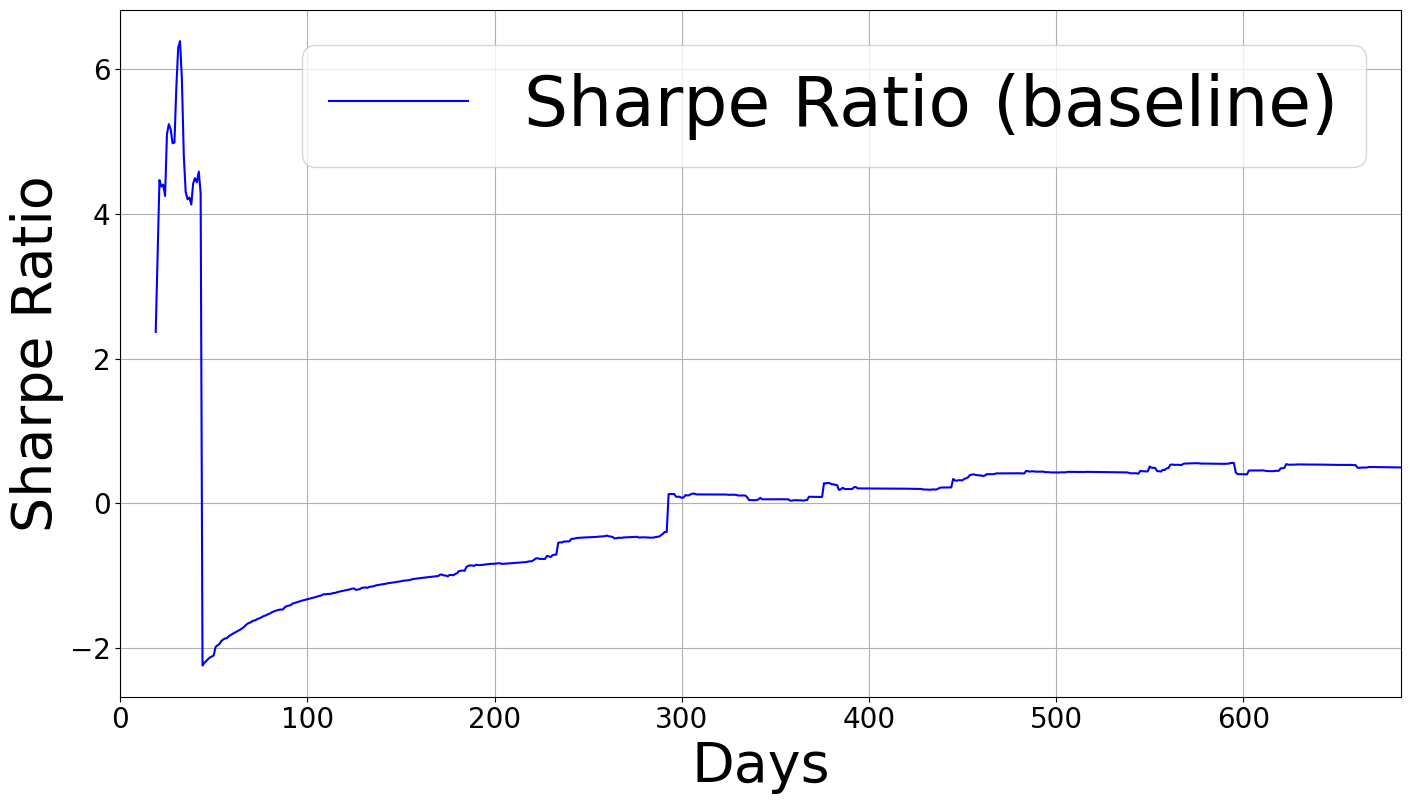

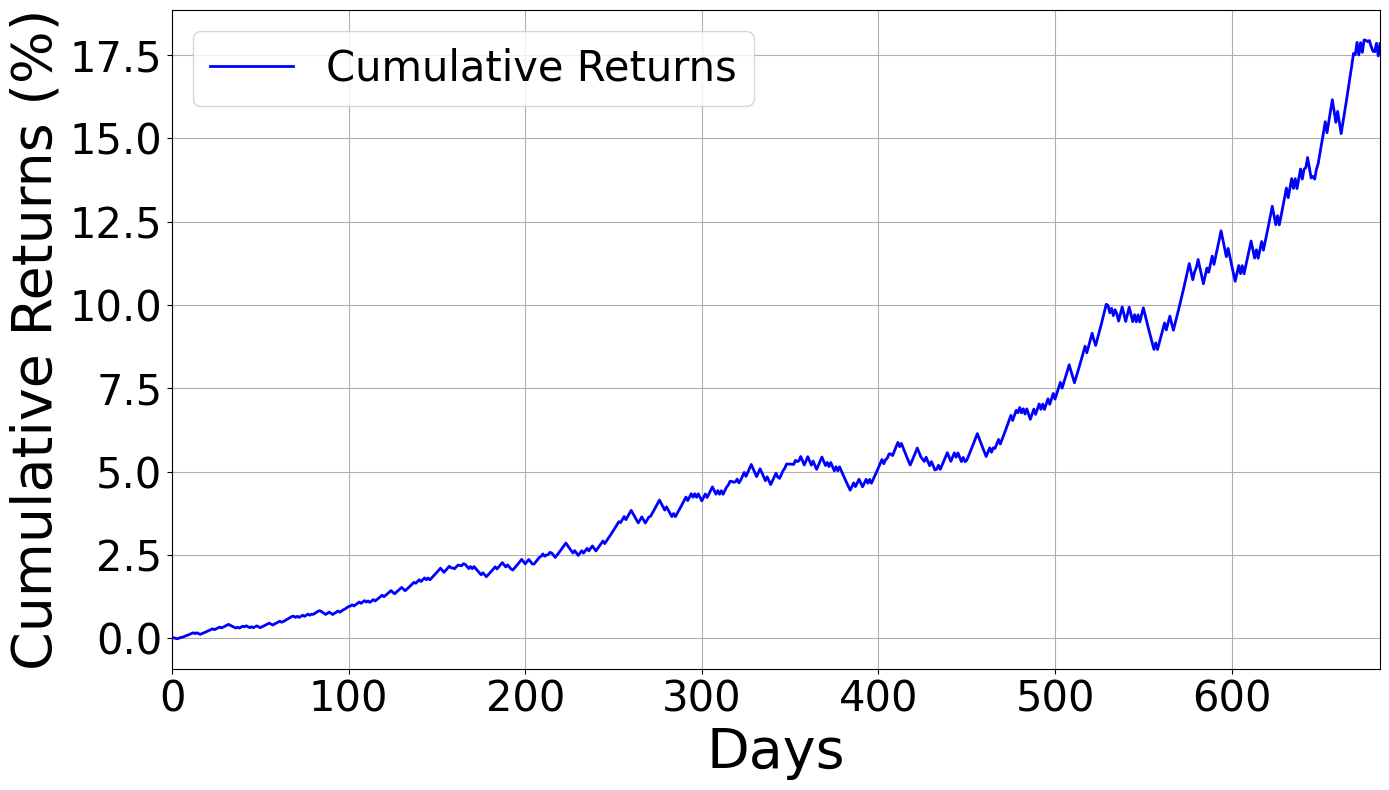

In [12]:
plot_dynamic_sharpe_ratio(portfolio_returns, folder=PLOTS_DIR)


plot_cumulative_returns_baseline(portfolio_returns, folder=PLOTS_DIR)

# LSTM quarterly rolling retrain

In [13]:
MODEL_DIR = PROJECT_ROOT / 'notebooks/models/LSTM_rolling'
PLOTS_DIR = PROJECT_ROOT / 'notebooks/plots/baseline/LSTM_rolling'

In [14]:
# Load models and get predictions
predictions, actuals = get_predictions_quarterly_models(
    tickers,
    simulation_start_date,
    simulation_end_date,
    sequence_length,
    model_folder=MODEL_DIR,
    data_start=quarterly_data_start_date,
    train_mode="rolling"
)

predictions, actuals = trim_predictions_to_length(predictions, actuals, reference_window_length)

# Trading strategy
trading_signals = moving_average_strategy(predictions)

# Backtest the strategy
portfolio_returns = simulate_trades_with_allocation(predictions, actuals, trading_signals, initial_capital=100000, allocation_percentage=0.1, slippage_rate=0.02, transaction_cost=0.005)

# Evaluate performance
sharpe_ratio = daily_sharpe_ratio(portfolio_returns)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Processing GOOGL...
Processing AMZN...
Processing AAPL...
Processing PEP...
Processing JNJ...
Processing PFE...
Processing MRK...
Processing ABBV...
Processing PG...
Processing KO...
Processing WMT...
Processing JPM...
Processing BAC...
Processing GS...
Processing V...
Processing XOM...
Processing CVX...
Processing COP...
Processing BP...
Processing BA...
Processing MMM...
Processing HON...
Processing GE...
Processing T...
Processing VZ...
Processing TMUS...
Processing HSY...
Processing DUK...
Processing SO...
Processing EXC...
Processing AEP...
Processing AMT...
Processing PLD...
Processing SPG...
Processing BHP...
Processing RIO...
Processing VALE...
Processing FCX...
Sharpe Ratio: 0.9175


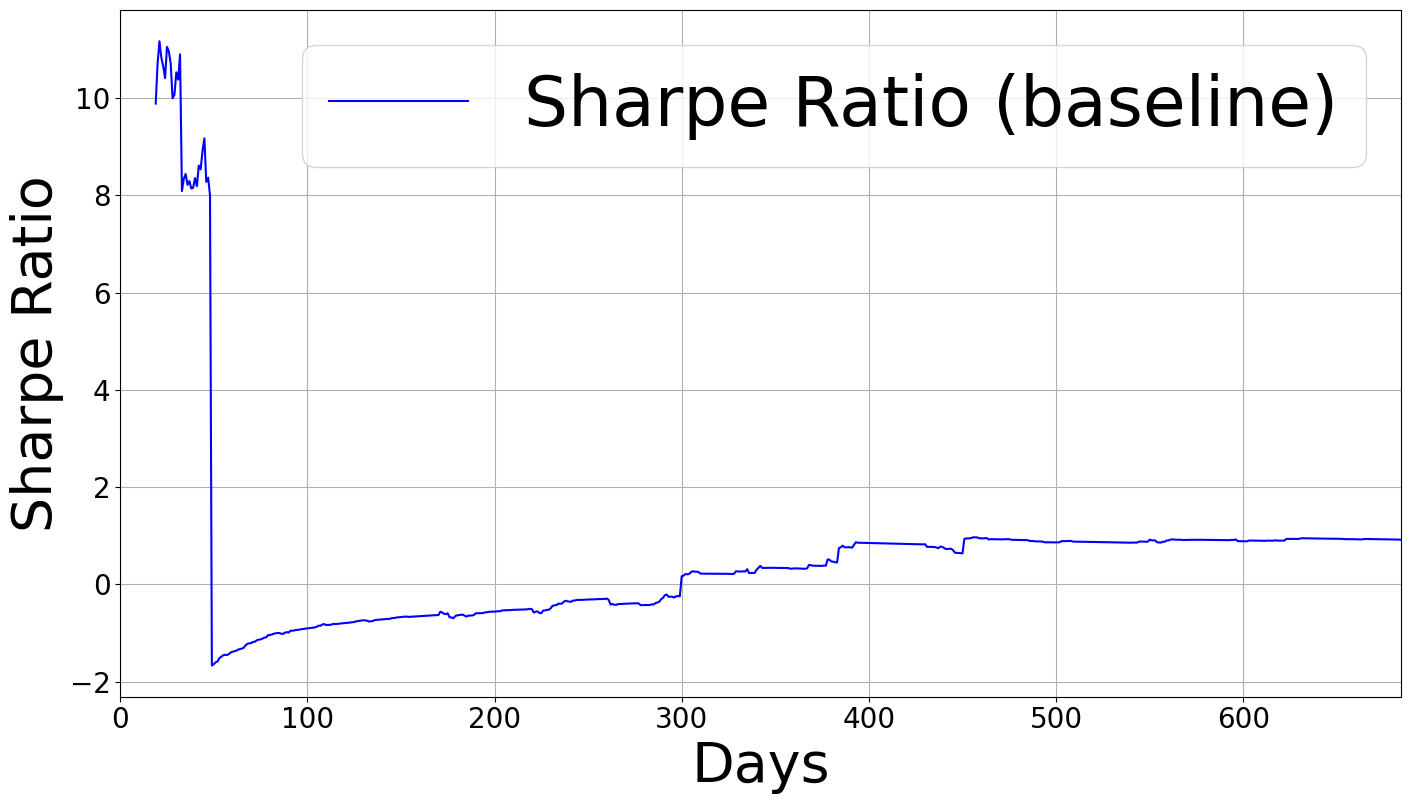

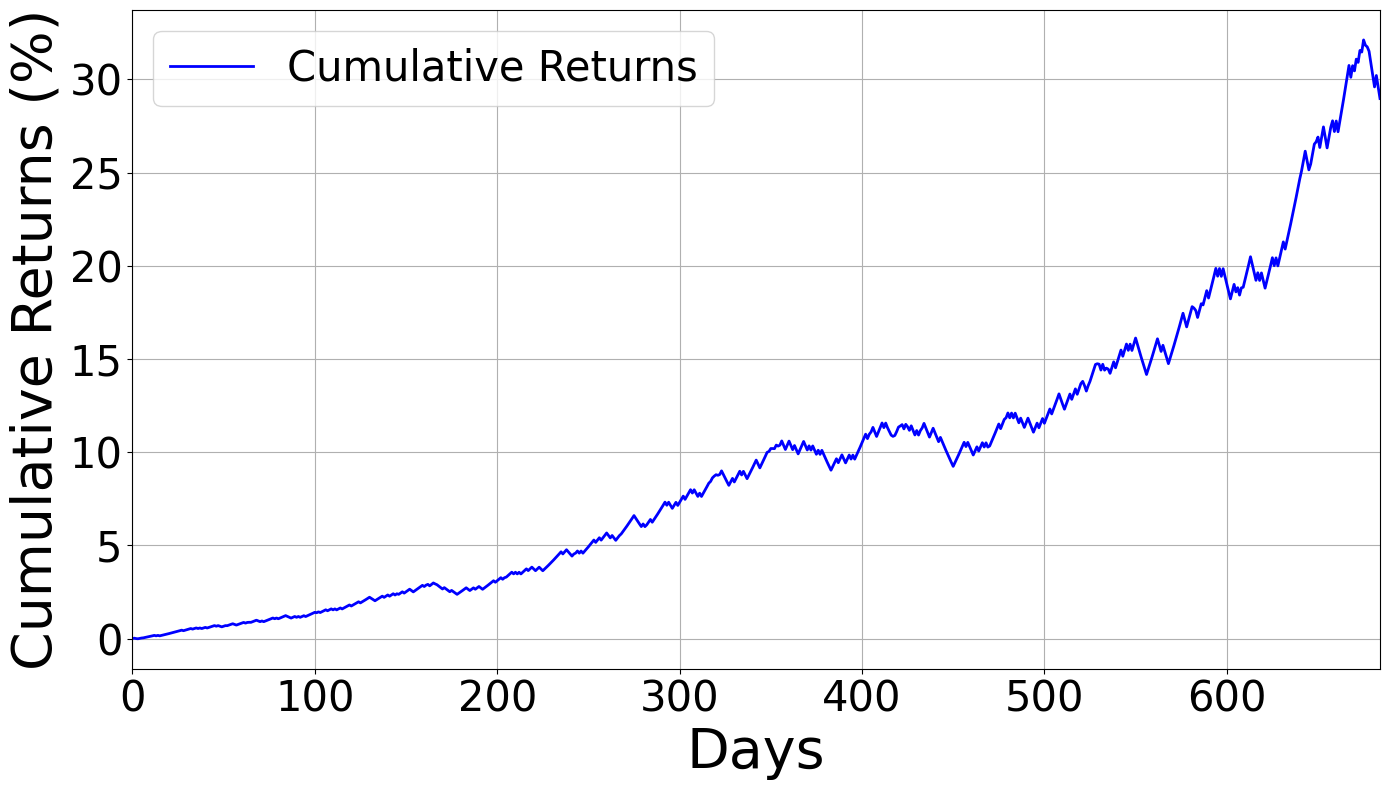

In [15]:
plot_dynamic_sharpe_ratio(portfolio_returns, folder=PLOTS_DIR)


plot_cumulative_returns_baseline(portfolio_returns, folder=PLOTS_DIR)